# Importações

In [10]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urlparse
from collections import deque
import os
import csv
from selenium.webdriver import Chrome
from selenium.webdriver.chrome.options import Options
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
import openai
import time
import numpy as np
from typing import List, Optional
from scipy import spatial

# Web Scraping

In [11]:
# URL principal do site
base_url = "https://henet.com.br/"

def get_urls(base_url):
    try:
        # Fazer a requisição para o site
        response = requests.get(base_url)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Encontrar todos os links
        urls = set()
        for link in soup.find_all('a', href=True):
            href = link['href']
            if href.startswith('/'):  # URLs relativas
                urls.add(base_url + href.lstrip('/'))
            elif href.startswith(base_url):  # URLs absolutas no domínio
                urls.add(href)
        
        return list(urls)
    except Exception as e:
        print(f"Erro ao acessar o site: {e}")
        return []

In [12]:
def get_text_from_url(urls):
    '''
        Recebe uma lista de URLs, faz o scraping do texto de cada página
        e salva o texto em arquivos <url>.txt, organizados por domínio.
    '''
    # Configurar o navegador no modo headless
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")

    # Inicializar o driver uma vez
    driver = Chrome(options=chrome_options)

    for url in urls:
        # Analisa a URL e pega o domínio
        local_domain = urlparse(url).netloc
        print(f"Processando domínio: {local_domain}")

        # Criar diretórios para armazenar os arquivos de texto
        base_text_path = f"text/{local_domain}/"
        os.makedirs(base_text_path, exist_ok=True)

        # Salvar o texto da página em um arquivo <url>.txt
        try:
            print(f"Coletando texto da URL: {url}")
            driver.get(url)
            page_soup = BeautifulSoup(driver.page_source, 'html.parser')
            text = page_soup.get_text()

            # Criar nome de arquivo a partir da URL
            filename = url[8:].replace("/", "_").replace("?", "_").replace(":", "_") + ".txt"
            filepath = os.path.join(base_text_path, filename)

            # Salvar texto em um arquivo
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text)

            print(f"Texto salvo em: {filepath}")
        except Exception as e:
            print(f"Erro ao processar {url}: {e}")

    # Fechar o navegador
    driver.quit()

In [13]:
# Obter todas as URLs principais do site
urls = get_urls(base_url)

# Salvar as URLs em um arquivo CSV para referência
with open("urls.csv", mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["URLs"])
    writer.writerows([[url] for url in urls])

print("URLs salvas em 'urls.csv'.")

# Fazer o scraping do texto das URLs e salvar como .txt
get_text_from_url(urls)

URLs salvas em 'urls.csv'.
Processando domínio: henet.com.br
Coletando texto da URL: https://henet.com.br/solucoes-empresariais
Texto salvo em: text/henet.com.br/henet.com.br_solucoes-empresariais.txt
Processando domínio: henet.com.br
Coletando texto da URL: https://henet.com.br/wp-content/uploads/2022/06/Contrato-Servicos-HE-NET.pdf
Texto salvo em: text/henet.com.br/henet.com.br_wp-content_uploads_2022_06_Contrato-Servicos-HE-NET.pdf.txt
Processando domínio: henet.com.br
Coletando texto da URL: https://henet.com.br/fale-conosco
Texto salvo em: text/henet.com.br/henet.com.br_fale-conosco.txt
Processando domínio: henet.com.br
Coletando texto da URL: https://henet.com.br/blog/novas-tecnologias-rede-pequeno-provedor
Texto salvo em: text/henet.com.br/henet.com.br_blog_novas-tecnologias-rede-pequeno-provedor.txt
Processando domínio: henet.com.br
Coletando texto da URL: https://henet.com.br/blog/sinais-empresa-link-dedicado
Texto salvo em: text/henet.com.br/henet.com.br_blog_sinais-empresa-l

# Pré Processamento de dados

In [14]:
def remove_newlines(serie):
    '''
        Essa função recebe uma série e remove as quebras de linha excessivas
        e múltiplos espaços em branco.
    '''
    # Substituir todas as quebras de linha por espaço
    serie = serie.str.replace('\n', ' ', regex=False)
    serie = serie.str.replace('\\n', ' ', regex=False)

    # Substituir múltiplos espaços por um único espaço
    serie = serie.str.replace(r'\s+', ' ', regex=True)

    # Remover espaços no início e no fim de cada texto
    serie = serie.str.strip()

    return serie

In [15]:
# Criar uma lista para armazenar os arquivos de texto
texts = []

# Remover "http://" ou "https://" do domínio
domain_clean = base_url.replace("http://", "").replace("https://", "")

# Verificar se o diretório existe
text_dir = f"text/{domain_clean}/"
if os.path.exists(text_dir):    
    # Obter todos os arquivos de texto no diretório de texto
    for file in os.listdir(text_dir):
        # Abrir o arquivo e ler o texto
        with open(os.path.join(text_dir, file), "r", encoding="utf-8") as f:
            text = f.read()
            # Omita as primeiras 20 linhas e as últimas 4 linhas e, em seguida, substitua '-', '_', e '#update' com espaços
            processed_name = file[20:-4].replace('-', ' ').replace('_', ' ').replace('#update', '')
            texts.append((processed_name, text))
else:
    print(f"O diretório {text_dir} não existe.")

# Criar um DataFrame a partir da lista de textos
df = pd.DataFrame(texts, columns=['page_name', 'text'])

# Definir a coluna de texto para ser o texto bruto com as novas linhas removidas
df['text'] = df['page_name'] + ". " + df['text'].str.replace(r"[\n\r]", " ", regex=True)

# Substituir valores NaN em 'page_name' com "página sem nome"
df['page_name'] = df['page_name'].fillna('página sem nome')

# Criar o diretório para armazenar o arquivo CSV, caso não exista
output_dir = "processed/"
os.makedirs(output_dir, exist_ok=True)

# Salvar o DataFrame em um arquivo CSV
output_path = os.path.join(output_dir, "scraped.csv")
df.to_csv(output_path, index=False, encoding="utf-8")

print(f"CSV salvo em: {output_path}")
df.head()

CSV salvo em: processed/scraped.csv


,page_name,text
0,,. Home - He-Net - Internet do seu jeito...
1,net,net. Blog He-Net - Conteúdo do seu jeit...
2,,. Blog He-Net - Conteúdo do seu jeito. ...
3,,. Blog He-Net - Conteúdo do seu jeito. ...
4,vas tecnologias rede pequeno provedor,vas tecnologias rede pequeno provedor. ...


In [16]:
print("Checando número de páginas extraidas e urls informadas \n")
print("Número de páginas",df.shape[0])
print("\nNúmero de urls informadas",len(urls))

Checando número de páginas extraidas e urls informadas 

Número de páginas 18

Número de urls informadas 16


# Tokens

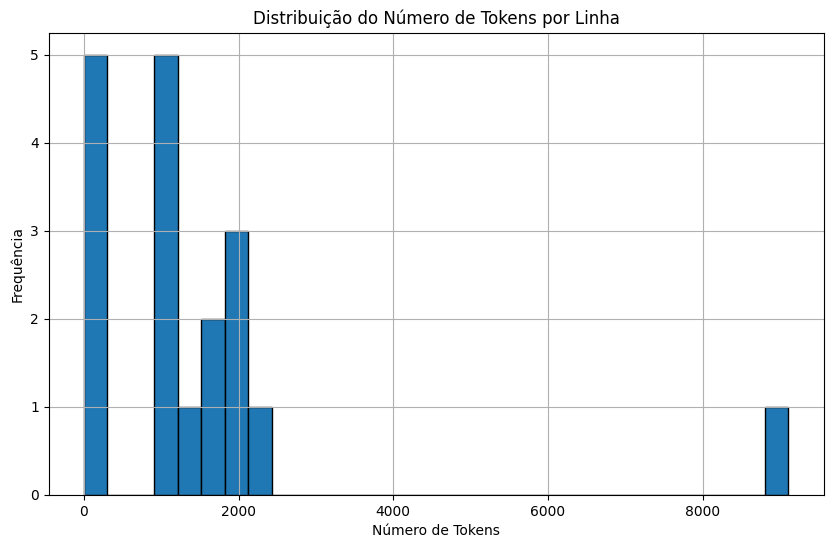

In [17]:
# Carregar o tokenizador cl100k_base que foi projetado para funcionar com o modelo ada-002
tokenizer = tiktoken.get_encoding("cl100k_base")

# Carregar o arquivo CSV onde os dados estão armazenados
df = pd.read_csv('processed/scraped.csv')

# Renomear as colunas, se necessário, de acordo com a sua estrutura
df.columns = ['page_name', 'text']  # Ajuste as colunas conforme necessário

# Tokenize o texto e salve o número de tokens em uma nova coluna
df['n_tokens'] = df['text'].apply(lambda x: len(tokenizer.encode(x)))

# Visualize a distribuição do número de tokens por linha usando um histograma
plt.figure(figsize=(10, 6))
df['n_tokens'].hist(bins=30, edgecolor='black')
plt.title('Distribuição do Número de Tokens por Linha')
plt.xlabel('Número de Tokens')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

In [18]:
# Substituir valores NaN em 'page_name' com "página sem nome"
df['page_name'] = df['page_name'].fillna('página sem nome')
df.head()


,page_name,text,n_tokens
0,página sem nome,. Home - He-Net - Internet do seu jeito...,1871
1,net,net. Blog He-Net - Conteúdo do seu jeit...,932
2,página sem nome,. Blog He-Net - Conteúdo do seu jeito. ...,931
3,página sem nome,. Blog He-Net - Conteúdo do seu jeito. ...,931
4,vas tecnologias rede pequeno provedor,vas tecnologias rede pequeno provedor. ...,1896


In [19]:
# Função para dividir o texto em partes de um número máximo de tokens
def split_into_many(text, max_tokens=500):
    # Dividir o texto em frases
    sentences = text.split('. ')
    
    # Obter o número de tokens para cada sentença
    n_tokens = [len(tokenizer.encode(" " + sentence)) for sentence in sentences]
    
    chunks = []
    tokens_so_far = 0
    chunk = []

    # Percorrer as sentenças e os tokens unidos em uma tupla
    for sentence, token in zip(sentences, n_tokens):
        # Se o número de tokens até o momento mais o número de tokens na frase atual for maior 
        # do que o número máximo de tokens, adicione o bloco à lista de blocos e redefina
        # o bloco e os tokens até o momento
        if tokens_so_far + token > max_tokens:
            chunks.append(". ".join(chunk) + ".")
            chunk = []
            tokens_so_far = 0

        # Se o número de tokens na frase atual for maior que o número máximo de 
        # tokens, vá para a próxima sentença
        if token > max_tokens:
            continue

        # Caso contrário, adicione a frase ao bloco e adicione o número de tokens ao total
        chunk.append(sentence)
        tokens_so_far += token + 1

    return chunks

# Lista para armazenar os textos abreviados
shortened = []

# Percorrer o dataframe
for _, row in df.iterrows():
    # Se o texto for None, vá para a próxima linha
    if row['text'] is None:
        continue

    # Se o número de tokens for maior que o número máximo de tokens, divida o texto em partes
    n_tokens = len(tokenizer.encode(row['text']))
    if n_tokens > 500:
        shortened += split_into_many(row['text'])
    else:
        shortened.append(row['text'])

# Criar um novo DataFrame com os textos divididos
df_shortened = pd.DataFrame(shortened, columns=['text'])

# Recalcular o número de tokens após dividir os textos
df_shortened['n_tokens'] = df_shortened['text'].apply(lambda x: len(tokenizer.encode(x)))


In [20]:
max_tokens = 500

# Função para dividir o texto em partes de um número máximo de tokens
def split_into_many(text, max_tokens = max_tokens):

    # Dividir o texto em frases
    sentences = text.split('. ')

    # Obter o número de tokens para cada sentença
    n_tokens = [len(tokenizer.encode(" " + sentence)) for sentence in sentences]
    
    chunks = []
    tokens_so_far = 0
    chunk = []

    # Percorrer as sentenças e os tokens unidos em uma tupla
    for sentence, token in zip(sentences, n_tokens):

        # Se o número de tokens até o momento mais o número de tokens na frase atual for maior 
        # do que o número máximo de tokens, adicione o bloco à lista de blocos e redefina
        # o bloco e os tokens até o momento
        if tokens_so_far + token > max_tokens:
            chunks.append(". ".join(chunk) + ".")
            chunk = []
            tokens_so_far = 0

        # Se o número de tokens na frase atual for maior que o número máximo de 
        # tokens, vá para a próxima sentença
        if token > max_tokens:
            continue

        # Caso contrário, adicione a frase ao bloco e adicione o número de tokens ao total
        chunk.append(sentence)
        tokens_so_far += token + 1

    return chunks
    

shortened = []

# Percorrer o dataframe
for row in df.iterrows():

    # Se o texto for None, vá para a próxima linha
    if row[1]['text'] is None:
        continue

    # Se o número de tokens for maior que o número máximo de tokens, divida o texto em partes
    if row[1]['n_tokens'] > max_tokens:
        shortened += split_into_many(row[1]['text'])
    
    # Caso contrário, adicione o texto à lista de textos abreviados
    else:
        shortened.append( row[1]['text'] )

array([[<Axes: title={'center': 'n_tokens'}>]], dtype=object)

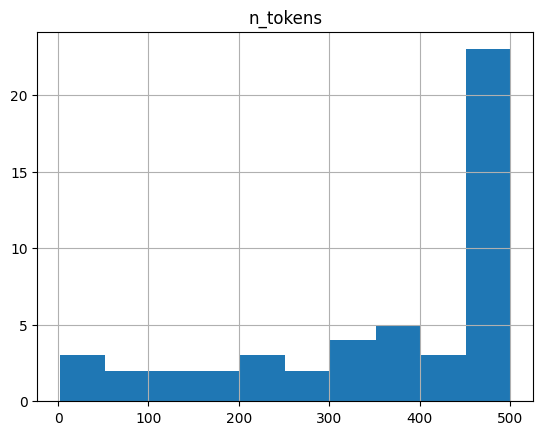

In [21]:
df = pd.DataFrame(shortened, columns = ['text'])
df['n_tokens'] = df.text.apply(lambda x: len(tokenizer.encode(x)))
df.hist(column='n_tokens')


In [22]:
num_tot_tokens = df['n_tokens'].sum()
print("Número total de tokens",num_tot_tokens)

Número total de tokens 17669


In [23]:
df.head()


,text,n_tokens
0,. Home - He-Net - Internet do seu jeito...,185
1,"Em alguns toques na tela, conecte-se com as so...",440
2,net. Blog He-Net - Conteúdo do seu jeit...,494
3,. Blog He-Net - Conteúdo do seu jeito. ...,493
4,. Blog He-Net - Conteúdo do seu jeito. ...,493


In [24]:
i = 0
for text in df['text']:
    i+=1
    
print("Número de trechos de texto com no máximo",max_tokens,"tokens :",i)

Número de trechos de texto com no máximo 500 tokens : 49


# Embedding

In [25]:
print("Custo total de treinamento do embedding: $",num_tot_tokens /1000 * 0.0001)


Custo total de treinamento do embedding: $ 0.0017669


In [26]:
def read_openai_api_key():
    with open('openai_secret.txt', 'r') as file:
        api_key = file.read().strip()
    return api_key

my_api_key = read_openai_api_key()

In [27]:
# Chave API

openai.api_key = read_openai_api_key()

In [28]:
i = 0
embeddings = []
for text in df['text']:
    time.sleep(2)
    print(i)
    try:
        embedding = openai.Embedding.create(input=text, engine='text-embedding-ada-002')['data'][0]['embedding']
        print("Fazendo embedding do texto")
        embeddings.append(embedding)
    except openai.error.RateLimitError:
        print("Rate limit error, esperando 20 segundo antes de tentar novamente")
        time.sleep(20)  
        embedding = openai.Embedding.create(input=text, engine='text-embedding-ada-002')['data'][0]['embedding']
        print("embedding texto depois de esperar 20 segundos")
        embeddings.append(embedding)
    i+=1

df['embeddings'] = embeddings
df.to_csv('processed/embeddings.csv')
df.head()

0
Fazendo embedding do texto
1
Fazendo embedding do texto
2
Fazendo embedding do texto
3
Fazendo embedding do texto
4
Fazendo embedding do texto
5
Fazendo embedding do texto
6
Fazendo embedding do texto
7
Fazendo embedding do texto
8
Fazendo embedding do texto
9
Fazendo embedding do texto
10
Fazendo embedding do texto
11
Fazendo embedding do texto
12
Fazendo embedding do texto
13
Fazendo embedding do texto
14
Fazendo embedding do texto
15
Fazendo embedding do texto
16
Fazendo embedding do texto
17
Fazendo embedding do texto
18
Fazendo embedding do texto
19
Fazendo embedding do texto
20
Fazendo embedding do texto
21
Fazendo embedding do texto
22
Fazendo embedding do texto
23
Fazendo embedding do texto
24
Fazendo embedding do texto
25
Fazendo embedding do texto
26
Fazendo embedding do texto
27
Fazendo embedding do texto
28
Fazendo embedding do texto
29
Fazendo embedding do texto
30
Fazendo embedding do texto
31
Fazendo embedding do texto
32
Fazendo embedding do texto
33
Fazendo embedding

,text,n_tokens,embeddings
0,. Home - He-Net - Internet do seu jeito...,185,"[0.0078585771843791, 0.010322204791009426, 0.0..."
1,"Em alguns toques na tela, conecte-se com as so...",440,"[-0.010794396512210369, 0.017076170071959496, ..."
2,net. Blog He-Net - Conteúdo do seu jeit...,494,"[0.002969978144392371, 0.013082201592624187, 0..."
3,. Blog He-Net - Conteúdo do seu jeito. ...,493,"[0.002850131131708622, 0.01222458016127348, 0...."
4,. Blog He-Net - Conteúdo do seu jeito. ...,493,"[0.002850131131708622, 0.01222458016127348, 0...."


In [29]:
df.head()

,text,n_tokens,embeddings
0,. Home - He-Net - Internet do seu jeito...,185,"[0.0078585771843791, 0.010322204791009426, 0.0..."
1,"Em alguns toques na tela, conecte-se com as so...",440,"[-0.010794396512210369, 0.017076170071959496, ..."
2,net. Blog He-Net - Conteúdo do seu jeit...,494,"[0.002969978144392371, 0.013082201592624187, 0..."
3,. Blog He-Net - Conteúdo do seu jeito. ...,493,"[0.002850131131708622, 0.01222458016127348, 0...."
4,. Blog He-Net - Conteúdo do seu jeito. ...,493,"[0.002850131131708622, 0.01222458016127348, 0...."


In [30]:
df=pd.read_csv('processed/embeddings.csv', index_col=0)
df['embeddings'] = df['embeddings'].apply(eval).apply(np.array)

df.head()

,text,n_tokens,embeddings
0,. Home - He-Net - Internet do seu jeito...,185,"[0.0078585771843791, 0.010322204791009426, 0.0..."
1,"Em alguns toques na tela, conecte-se com as so...",440,"[-0.010794396512210369, 0.017076170071959496, ..."
2,net. Blog He-Net - Conteúdo do seu jeit...,494,"[0.002969978144392371, 0.013082201592624187, 0..."
3,. Blog He-Net - Conteúdo do seu jeito. ...,493,"[0.002850131131708622, 0.01222458016127348, 0...."
4,. Blog He-Net - Conteúdo do seu jeito. ...,493,"[0.002850131131708622, 0.01222458016127348, 0...."


In [31]:
def distances_from_embeddings(
    query_embedding: List[float],
    embeddings: List[List[float]],
    distance_metric="cosine",
) -> List[float]:
    distance_metrics = {
        "cosine": spatial.distance.cosine,
        "L1": spatial.distance.cityblock,
        "L2": spatial.distance.euclidean,
        "Linf": spatial.distance.chebyshev,
    }
    distances = [
        distance_metrics[distance_metric](query_embedding, embedding)
        for embedding in embeddings
    ]
    return distances

In [32]:
def create_context(question, df, max_len=1800, size="ada"):
    """
    Cria um contexto para uma pergunta encontrando o contexto mais similar no conjunto de embeddings gerado utilizando o Custom Knowledge.
    """

    # Obter a embeddings para a pergunta que foi feita
    q_embeddings = openai.Embedding.create(input=question, engine='text-embedding-ada-002')['data'][0]['embedding']

    # Obter as distâncias a partir dos embeddings
    df['distances'] = distances_from_embeddings(q_embeddings, df['embeddings'].values, distance_metric='cosine')


    returns = []
    cur_len = 0

    # Classifique por distância e adicione o texto ao contexto
    for i, row in df.sort_values('distances', ascending=True).iterrows():
        
        # Adicionar o comprimento do texto ao comprimento atual
        cur_len += row['n_tokens'] + 4
        
        # Se o contexto for muito longo, quebre
        if cur_len > max_len:
            break
        
        # Caso contrário, adicione-o ao texto que está sendo retornado
        returns.append(row["text"])

    # Retornar o contexto
    return "\n\n###\n\n".join(returns)

In [38]:
def answer_question(
                    df,
                    model="gpt-3.5-turbo",  
                    question="O que é a Henet?",
                    max_len=1800,
                    size="ada",
                    debug=False,
                    max_tokens=150,
                    stop_sequence=None):
    """
    Responder a uma pergunta com base no contexto mais semelhante dos textos do dataframe
    """
    # Criar o contexto com base no DataFrame e na pergunta
    context = create_context(
        question,
        df=df,
        max_len=max_len,
        size=size,
    )
    
    if debug:
        # Garantir que o context seja uma string antes de concatená-lo
        print("Context:\n" + str(context))
        print("\n\n")

    try:
        # Ajustar para o modelo de chat e usar o endpoint correto
        response = openai.ChatCompletion.create(
            model=model,  # Exemplo: 'gpt-3.5-turbo'
            messages=[
                {"role": "system", "content": "Você é um assistente útil. Responda de forma clara e objetiva."},
                {"role": "user", "content": f"Contexto: {str(context)}\n\nPergunta: {question}"}
            ],
            max_tokens=max_tokens,
            temperature=0.7,  # Leve variação para respostas mais criativas
            top_p=1,
            frequency_penalty=0,
            presence_penalty=0,
            stop=stop_sequence
        )
        
        # Retornar a resposta gerada
        return response['choices'][0]['message']['content'].strip()
    
    except Exception as e:
        print(f"Erro: {e}")
        return "Desculpe, ocorreu um erro ao processar sua solicitação."

In [39]:
resposta = answer_question(df=df, question="O que é a henet")
print(resposta)

A He-Net é uma empresa de telecomunicações que oferece serviços de internet, TV e telefonia móvel, atuando principalmente na Bahia. A empresa se destaca por sua história de sucesso e busca proporcionar uma experiência única de conectividade para seus clientes.
